In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: Tesla T4


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/ai-vs-human-generated-dataset


In [3]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt


In [ ]:
class AIVSHumanDataset(Dataset):
    def __init__(self, csv_path, img_folder, transform=None):
        self.data = pd.read_csv(csv_path)
        self.img_folder = img_folder
        self.transform = transform

        #  Dynamically choose the correct image column
        if 'file_name' in self.data.columns:
            self.image_col = 'file_name'
        elif 'id' in self.data.columns:
            self.image_col = 'id'
        else:
            raise ValueError("Neither 'file_name' nor 'id' found in CSV columns.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_folder, os.path.basename(row[self.image_col]))

        label = int(row['label']) if 'label' in row else -1  # test.csv has no label
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label


In [5]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])


In [6]:
def get_transforms():
    return T.Compose([
        T.Resize((128, 128)),
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])


In [7]:
csv_path = "/kaggle/input/ai-vs-human-generated-dataset/train.csv"
img_folder = "/kaggle/input/ai-vs-human-generated-dataset/train_data"

In [8]:
dataset = AIVSHumanDataset(csv_path, img_folder, transform=get_transforms())
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)


torch.Size([8, 3, 128, 128]) tensor([1, 0, 1, 1, 1, 1, 1, 1])


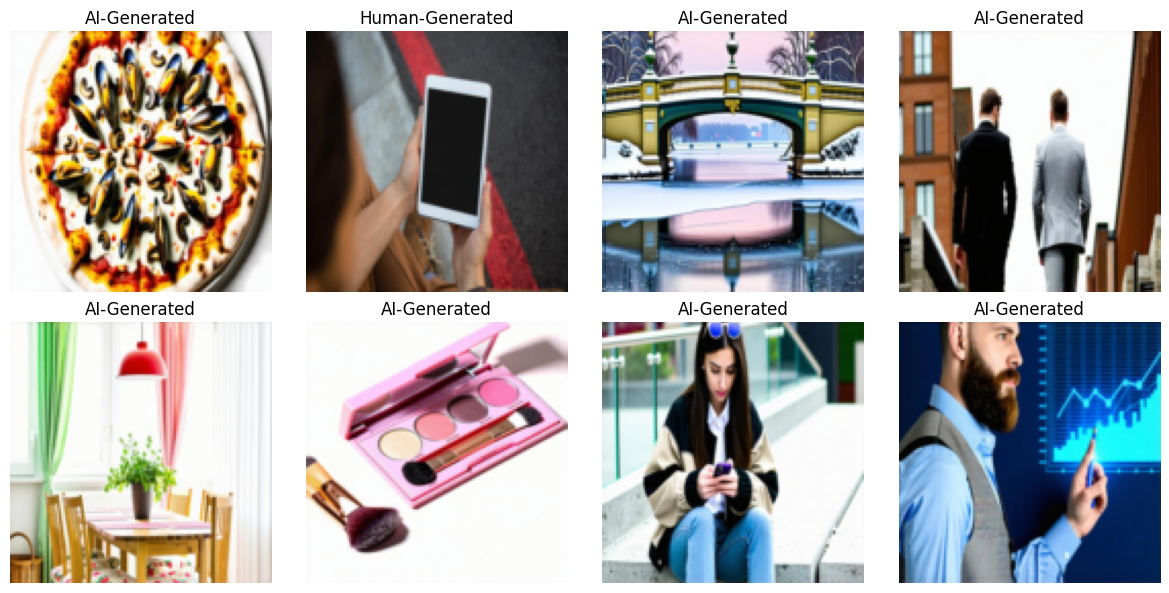

In [9]:
def imshow(img_tensor, label):
    img = img_tensor.permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # Unnormalize
    img = img.clip(0, 1)
    plt.imshow(img)
    plt.title("AI-Generated" if label == 1 else "Human-Generated")
    plt.axis('off')

images, labels = next(iter(dataloader))
print(images.shape, labels)

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    imshow(images[i], labels[i].item())
plt.tight_layout()
plt.show()


Phase -2

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import timm
from tqdm import tqdm
import numpy as np


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model(
    'vit_tiny_patch16_224',
    pretrained=True
)
model.head = nn.Linear(model.head.in_features, 1)

#  Allow non-224 image sizes
model.patch_embed.img_size = (128, 128)
model.patch_embed.grid_size = (128 // 16, 128 // 16)

# Recalculate positional embeddings
num_patches = (128 // 16) * (128 // 16)
model.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, model.pos_embed.shape[-1]))

model = model.to(device)


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [12]:
full_dataset = AIVSHumanDataset("/kaggle/input/ai-vs-human-generated-dataset/train.csv", "/kaggle/input/ai-vs-human-generated-dataset/train_data", transform=get_transforms())

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_set, val_set = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)


In [13]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()


/tmp/ipykernel_31/178857144.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [16]:
def evaluate(model, dataloader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).long()

            correct += (preds.view(-1) == labels).sum().item()
            total += labels.size(0)

    return correct / total


In [18]:
def train(model, train_loader, val_loader, epochs=10, patience=3):
    best_val_acc = 0
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for images, labels in tqdm(train_loader):
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        val_acc = evaluate(model, val_loader)
        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "vit_tiny_best.pth")
            print("✅ Best model saved")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"⏳ No improvement. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("🛑 Early stopping triggered.")
                break


In [19]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

train(model, train_loader, val_loader, epochs=10, patience=3)


  0%|          | 0/1999 [00:00<?, ?it/s]/tmp/ipykernel_31/2410402529.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 1999/1999 [07:39<00:00,  4.35it/s]


Epoch 1 | Train Acc: 0.9753, Val Acc: 0.9806
✅ Best model saved


100%|██████████| 1999/1999 [07:33<00:00,  4.41it/s]


Epoch 2 | Train Acc: 0.9890, Val Acc: 0.9745
⏳ No improvement. Patience: 1/3


100%|██████████| 1999/1999 [07:29<00:00,  4.44it/s]


...

Epoch 4 | Train Acc: 0.9960, Val Acc: 0.9817
⏳ No improvement. Patience: 1/3


100%|██████████| 1999/1999 [07:35<00:00,  4.39it/s]


Epoch 5 | Train Acc: 0.9966, Val Acc: 0.9828
⏳ No improvement. Patience: 2/3


100%|██████████| 1999/1999 [07:33<00:00,  4.41it/s]


Epoch 6 | Train Acc: 0.9968, Val Acc: 0.9834
⏳ No improvement. Patience: 3/3
🛑 Early stopping triggered.


In [20]:
# Load best model weights
model.load_state_dict(torch.load("vit_tiny_best.pth"))
model.eval()


/tmp/ipykernel_31/3991036502.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vit_tiny_best.pth"))


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()


In [21]:
test_csv = "/kaggle/input/ai-vs-human-generated-dataset/test.csv"
test_imgs = "/kaggle/input/ai-vs-human-generated-dataset/test_data_v2"

test_df = pd.read_csv(test_csv)
test_dataset = AIVSHumanDataset(test_csv, test_imgs, transform=get_transforms())
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [22]:
# Use val_loader and run model on it like this
val_preds = []
val_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).long().cpu().numpy()
        val_preds.extend(preds.flatten())
        val_labels.extend(labels.numpy())

from sklearn.metrics import classification_report
print(classification_report(val_labels, val_preds, target_names=["Human", "AI"], zero_division=0))


              precision    recall  f1-score   support

       Human       0.98      0.98      0.98      8008
          AI       0.98      0.98      0.98      7982

    accuracy                           0.98     15990
   macro avg       0.98      0.98      0.98     15990
weighted avg       0.98      0.98      0.98     15990



In [24]:
all_preds = []

model.eval()
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).long().cpu().numpy().flatten()
        all_preds.extend(preds)


In [25]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "label": all_preds
})
submission.to_csv("submission.csv", index=False)
print("✅ Submission file created: submission.csv")

✅ Submission file created: submission.csv


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


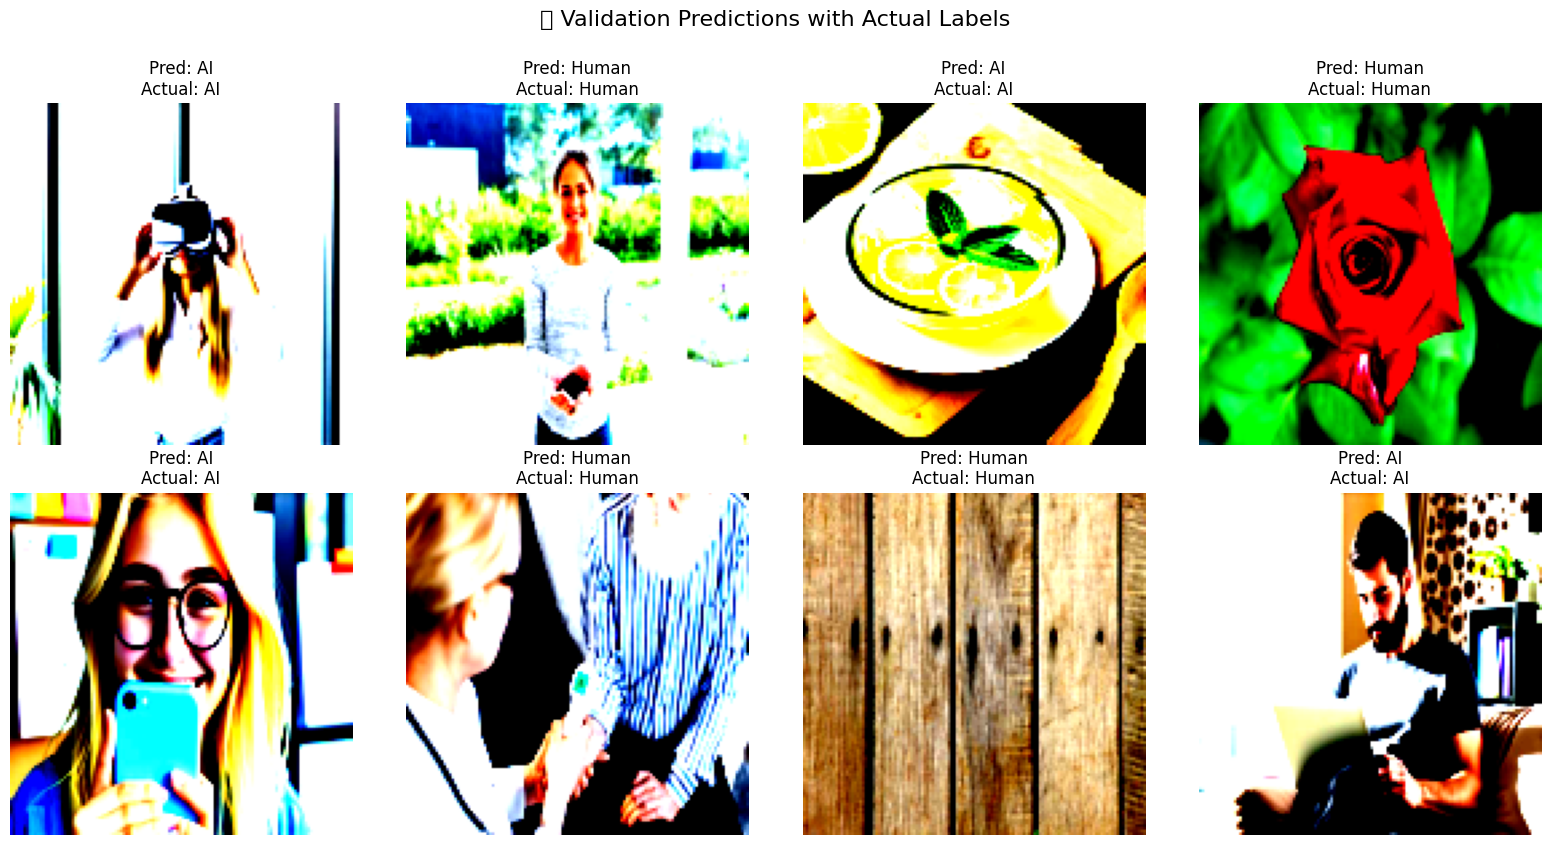

In [ ]:
import matplotlib.pyplot as plt
import random

# Use val_loader and randomly pick 8 samples
val_batch = next(iter(DataLoader(val_set, batch_size=64, shuffle=True)))

images, true_labels = val_batch
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    probs = torch.sigmoid(outputs)
    pred_labels = (probs > 0.5).long().cpu().numpy().flatten()

# Plot 8 random samples
indices = random.sample(range(len(images)), 8)

plt.figure(figsize=(16, 8))
for i, idx in enumerate(indices):
    image = images[idx].cpu().permute(1, 2, 0).numpy()
    true = int(true_labels[idx].item())
    pred = int(pred_labels[idx])

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(f"Pred: {'AI' if pred else 'Human'}\nActual: {'AI' if true else 'Human'}", fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.suptitle(" Validation Predictions with Actual Labels", fontsize=16, y=1.05)
plt.show()
